<a href="https://colab.research.google.com/github/Boss-diamond/global-cattle-disease-detection/blob/main/global_cattle_disease_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss



In [ ]:
cattle_disease_file_path = "global_cattle_disease_detection_dataset.csv"
global_cattle_data = pd.read_csv(cattle_disease_file_path)
le = LabelEncoder()


checking for null

In [ ]:
co = (global_cattle_data.isnull().sum() / len(global_cattle_data)) * 100
print(co[co > 0].sort_values(ascending= False))

Series([], dtype: float64)


drops dupllicates

In [ ]:
global_cattle_data.drop_duplicates(inplace=True)

In [ ]:
#plt.scatter(global_cattle_data['Feed_Type'], global_cattle_data['Age_Months'])

the rate of being healthy


<Axes: xlabel='Disease_Status'>

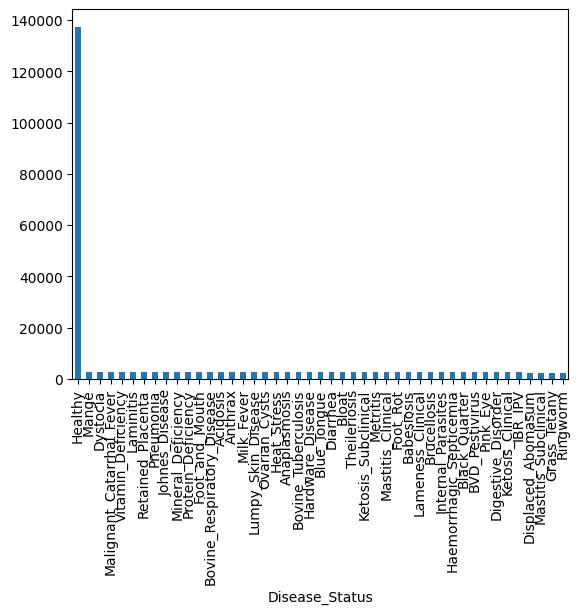

In [ ]:
print('the rate of being healthy')
global_cattle_data['Disease_Status'].value_counts().plot(kind = 'bar')


#checking data that needs to be encoded

In [ ]:
global_cattle_data.select_dtypes(include='object').columns

Index(['Cattle_ID', 'Breed', 'Region', 'Country', 'Climate_Zone',
       'Management_System', 'Lactation_Stage', 'Feed_Type', 'Season', 'Date',
       'Farm_ID', 'Disease_Status'],
      dtype='object')

econding of feature

In [ ]:
global_cattle_data_encoded = pd.get_dummies(global_cattle_data, columns=[ 'Breed', 'Region', 'Climate_Zone', 'Management_System', 'Feed_Type', 'Season', ], drop_first=True)

In [ ]:
global_cattle_data_encoded['Disease_Status_encoded'] = le.fit_transform(global_cattle_data_encoded['Disease_Status'])


definition of neccessary feautures

In [ ]:
not_feature = ['Weight_kg','Walking_Distance_km','Lactation_Stage','Resting_Hours','Humidity_percent','Housing_Score','Cattle_ID','Country',  'Date',  'Farm_ID', 'Disease_Status', 'Date','Milking_Interval_hrs', 'Milk_Yield_L' ]

In [ ]:
[print(list(global_cattle_data_encoded.columns))]

['Cattle_ID', 'Country', 'Age_Months', 'Weight_kg', 'Parity', 'Lactation_Stage', 'Days_in_Milk', 'Feed_Quantity_kg', 'Water_Intake_L', 'Walking_Distance_km', 'Grazing_Duration_hrs', 'Rumination_Time_hrs', 'Resting_Hours', 'Body_Temperature_C', 'Heart_Rate_bpm', 'Respiratory_Rate', 'Ambient_Temperature_C', 'Humidity_percent', 'Housing_Score', 'Milk_Yield_L', 'FMD_Vaccine', 'Brucellosis_Vaccine', 'HS_Vaccine', 'BQ_Vaccine', 'Anthrax_Vaccine', 'IBR_Vaccine', 'BVD_Vaccine', 'Rabies_Vaccine', 'Previous_Week_Avg_Yield', 'Body_Condition_Score', 'Milking_Interval_hrs', 'Date', 'Farm_ID', 'Disease_Status', 'Breed_Ankole', 'Breed_Australian_Friesian_Sahiwal', 'Breed_Australian_Milking_Zebu', 'Breed_Ayrshire', 'Breed_Boran', 'Breed_Brown_Swiss', 'Breed_Butana', 'Breed_Danish_Red', 'Breed_Deoni', 'Breed_Exotic_Local_Cross', 'Breed_Fleckvieh', 'Breed_Gangatiri', 'Breed_Gir', 'Breed_Girolando', 'Breed_Guernsey', 'Breed_Hariana', 'Breed_Holstein-Friesian', 'Breed_Holstein_Zebu_Cross', 'Breed_Illawarr

[None]

In [ ]:
global_cattle_data_encoded["Disease_Status_encoded"].head()

,Disease_Status_encoded
0,16
1,26
2,20
3,20
4,20


In [ ]:
X = global_cattle_data_encoded.drop(not_feature,  axis=1)
y = global_cattle_data_encoded['Disease_Status_encoded']

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
X_temp, X_test, y_temp, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.125, random_state=42)

In [ ]:
print(np.isnan(X_scaled).sum())

0


In [ ]:
# model_lr = LogisticRegression(multi_class='ovr',   # one-vs-rest
# solver='saga',       # fast for large datasets
# max_iter=1000,       # enough iterations
# verbose=1,random_state=0)
# model_lr.fit(X_train, y_train)
# val_work = model_lr.score(X_val, y_val)
# print("val accuracy:", val_work)
# train_acclr = model_lr.score(X_train, y_train)
# print("val accuracy:", train_acclr)
# y_pred_lr = model_lr.predict(X_test)
# y_pred_label = pd.Series(le.inverse_transform(y_pred_lr))
# print(y_pred_label)

In [ ]:
model_rf = RandomForestClassifier(
    max_depth=50,
    max_features="sqrt",
    n_jobs=-1,
    verbose=1,
    n_estimators = 300,
    random_state=0)
model_rf.fit(X_train, y_train)
valrf_work = model_rf.score(X_val, y_val)
print("val accuracy:", valrf_work)
train_accrf = model_rf.score(X_train, y_train)
print("train accuracy:", train_accrf)
y_pred_rf = model_rf.predict(X_test)
test_accrf = model_rf.score(X_test, y_test)
print("test accuracy:", test_accrf)
y_pred_prob = model_rf.predict_proba(X_test)
loss = log_loss(y_test, y_pred_prob)
print("Loss:", loss)
y_pred_label = pd.Series(le.inverse_transform(y_pred_rf))
print(y_pred_label)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   30.0s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  3.0min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.4s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    1.7s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    2.7s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.


val accuracy: 0.91908


[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    3.2s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:   17.9s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:   33.9s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.


train accuracy: 1.0


[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    2.5s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    5.6s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    7.5s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.8s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    3.3s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    5.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.


test accuracy: 0.92006


[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.9s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    4.6s


Loss: 0.8644355873318084
0                    Healthy
1                Brucellosis
2                    Healthy
3                    Healthy
4        Bovine_Tuberculosis
                ...         
49995                Healthy
49996                Healthy
49997                Healthy
49998            Heat_Stress
49999                Healthy
Length: 50000, dtype: object


[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    6.3s finished
